# chess-gnn: RL self-play fine-tuning

Fine-tunes an SL-pretrained checkpoint with **AlphaZero-style self-play**:
each self-play move runs a short PUCT MCTS, and the visit distribution is
used as a dense policy target (cross-entropy), with the game outcome as the
value target. This gives signal on every move even when games draw — the
previous REINFORCE-style setup was blind on most iterations because almost
every self-play game ended in a draw and the terminal reward was 0.

A `--algo reinforce` flag keeps the old behavior for comparison.

**Prerequisite:** an SL checkpoint (run `notebooks/train_sl.ipynb` first, or
supply an existing `sl_final.pt`). Starting RL from a randomly-initialized
model in chess is extremely slow and unlikely to learn anything useful.


In [1]:
# --- environment setup ---------------------------------------------------
import sys, subprocess, pathlib

IN_COLAB = "google.colab" in sys.modules
print("colab:", IN_COLAB)

REPO_URL = ""  # optional: set to your GitHub URL to auto-clone on Colab
REPO_DIR = pathlib.Path("/content/chess") if IN_COLAB else pathlib.Path.cwd().parent

if IN_COLAB:
    if REPO_URL and not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    elif not REPO_DIR.exists():
        from google.colab import files  # type: ignore
        print("No REPO_URL set — upload a zip of the repo (containing src/chess_gnn).")
        up = files.upload()
        name = next(iter(up))
        REPO_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.check_call(["unzip", "-q", name, "-d", str(REPO_DIR)])

    subprocess.check_call([
        "pip", "install", "-q",
        "torch", "torch-geometric", "python-chess", "zstandard", "tqdm",
    ])
    subprocess.check_call(["pip", "install", "-q", "-e", str(REPO_DIR)])

src_path = str((REPO_DIR / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import torch
print("torch:", torch.__version__)
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
# DEVICE = "cpu"
print("device:", DEVICE)

colab: False
torch: 2.11.0
device: mps


In [2]:
# --- locate the SL checkpoint to fine-tune -------------------------------
# On Colab you may want to mount Drive to persist checkpoints across sessions:
#   from google.colab import drive; drive.mount('/content/drive')
# and set SL_CKPT / RL_CKPT_DIR accordingly.

SL_CKPT = REPO_DIR / "checkpoints" / "sl" / "sl_final.pt"
RL_CKPT_DIR = REPO_DIR / "checkpoints" / "rl"
RL_CKPT_DIR.mkdir(parents=True, exist_ok=True)

assert SL_CKPT.exists(), f"SL checkpoint not found at {SL_CKPT}. Run train_sl.ipynb first or set SL_CKPT."
print("starting from:", SL_CKPT, f"({SL_CKPT.stat().st_size / 1e6:.1f} MB)")

# Read arch config from the SL checkpoint so we can rebuild the model consistently.
sl_state = torch.load(SL_CKPT, map_location="cpu")
ARCH = sl_state.get("config")
if ARCH is None:
    # Pre-config checkpoint — set these to match how it was trained.
    ARCH = {"hidden_dim": 128, "num_layers": 4, "num_heads": 4}
    print("[warn] no config in ckpt; assuming", ARCH)
else:
    print("arch:", ARCH)

starting from: /Users/jordanshivers/Box Sync/NewLab/competitions/chess/checkpoints/sl/sl_final.pt (1.2 MB)
arch: {'hidden_dim': 64, 'num_layers': 4, 'num_heads': 4, 'dropout': 0.0}


In [3]:
# --- sanity: play one self-play game with the SL model -------------------
from chess_gnn.model import load_model
from chess_gnn.selfplay import play_self_game

probe = load_model(SL_CKPT, device=DEVICE, **ARCH)
traj = play_self_game(probe, device=DEVICE, temperature=0.7, max_plies=100)
print(f"result: {traj.result} | plies: {len(traj.positions)} | "
      f"final reward sample: {traj.rewards[-1] if traj.rewards else None}")

result: * | plies: 100 | final reward sample: -0.0


In [ ]:
# --- fine-tune -----------------------------------------------------------
from chess_gnn.train_rl import train as train_rl

# AlphaZero-style fine-tune. MCTS self-play is the dominant cost; `mcts_sims`
# trades quality for wallclock (32 is cheap and still gives dense targets; 100+
# is closer to AlphaZero settings). On CPU this is slow — prefer GPU.
#
# Set `algo="reinforce"` to revert to the legacy terminal-reward path.
train_rl(
    sl_ckpt=SL_CKPT,
    ckpt_dir=RL_CKPT_DIR,
    iterations=50,           # bump to ~200+ for real fine-tuning
    games_per_iter=8,
    epochs_per_iter=2,
    batch_size=128,
    lr=1e-4,
    temperature=1.0,         # AZ: opening exploration; drops to ~0 after az_temperature_drop_ply
    entropy_coef=0.0,        # AZ doesn't need an entropy bonus; MCTS provides exploration
    value_coef=0.5,
    hidden_dim=ARCH["hidden_dim"],
    num_layers=ARCH["num_layers"],
    num_heads=ARCH["num_heads"],
    eval_every=5,
    eval_games=8,
    device=DEVICE,
    algo="az",
    mcts_sims=32,
    az_temperature_drop_ply=30,
)

iter    1 | games 8 | plies 644 | decisive 1/8 | pg 2.103 v 0.105 ent 2.277 | 248.3s
iter    2 | games 8 | plies 647 | decisive 0/8 | pg 2.050 v 0.016 ent 2.243 | 253.0s
iter    3 | games 8 | plies 560 | decisive 1/8 | pg 1.669 v 0.106 ent 1.921 | 220.7s
iter    4 | games 8 | plies 523 | decisive 1/8 | pg 1.580 v 0.079 ent 1.810 | 209.0s
iter    5 | games 8 | plies 525 | decisive 0/8 | pg 1.531 v 0.006 ent 1.730 | 207.9s
  eval vs baseline: {'wins': 1, 'draws': 6, 'losses': 1}
iter    6 | games 8 | plies 572 | decisive 0/8 | pg 1.393 v 0.003 ent 1.611 | 223.7s
iter    7 | games 8 | plies 503 | decisive 0/8 | pg 1.201 v 0.002 ent 1.431 | 207.8s
iter    8 | games 8 | plies 527 | decisive 0/8 | pg 1.144 v 0.001 ent 1.332 | 270.1s
iter    9 | games 8 | plies 528 | decisive 0/8 | pg 0.972 v 0.001 ent 1.148 | 253.8s
iter   10 | games 8 | plies 502 | decisive 0/8 | pg 0.917 v 0.001 ent 1.092 | 249.3s
  eval vs baseline: {'wins': 0, 'draws': 7, 'losses': 1}


In [6]:
# --- load the fine-tuned model and compare head-to-head vs the SL baseline
from chess_gnn.train_rl import evaluate

latest = sorted(RL_CKPT_DIR.glob("rl_*.pt"))[-1]
print("loading", latest)

tuned = load_model(latest, device=DEVICE, **ARCH)
baseline = load_model(SL_CKPT, device=DEVICE, **ARCH)

stats = evaluate(tuned, baseline, device=DEVICE, num_games=20, temperature=0.05)
print("RL vs SL:", stats)

loading /Users/jordanshivers/Box Sync/NewLab/competitions/chess/checkpoints/rl/rl_iter5.pt
RL vs SL: {'wins': 0, 'draws': 20, 'losses': 0}


   e7e6  0.315
   d7d6  0.235
   d7d5  0.205
   g8f6  0.155
   b8c6  0.060
   c5c4  0.015
   e7e5  0.015


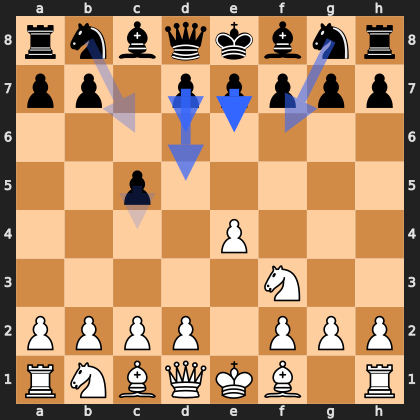

In [7]:
# --- visualize predictions of the fine-tuned model -----------------------
import chess
from IPython.display import SVG, display

from chess_gnn.play import GNNAgent
from chess_gnn.viz import render_prediction_svg

# num_simulations=200 enables PUCT MCTS; set to 0 for raw policy (much faster).
agent = GNNAgent(tuned, device=DEVICE, default_temperature=0.3, num_simulations=200)

board = chess.Board()
board.push_san("e4"); board.push_san("c5"); board.push_san("Nf3")
ranking = agent.rank_moves(board)
for m, p in list(zip(ranking.moves, ranking.probabilities))[:8]:
    print(f"  {m.uci():>5s}  {p:.3f}")
display(SVG(render_prediction_svg(board, ranking, topk=6)))